# exp02 — Сравнение моделей: Linear → Ridge → RandomForest → XGBoost

## Цель
Обучить 4 регрессионные модели разного уровня сложности на данных о подержанных
автомобилях, сравнить качество по метрикам MAE / RMSE / R² и выбрать лучшую
модель-кандидата для дальнейшего тюнинга и деплоя.

## Данные
- **Источник:** обработанный датасет из `exp01` — `data/processed/vehicles_clean.parquet`
- **Если `exp01` не запускался:** укажите `DATA_PROC_DIR` так, чтобы скрипт
  скачал и обработал данные на лету (режим `FORCE_REPROCESS = True`).

## 0. Конфигурация

In [23]:
from pathlib import Path


PROJECT_ROOT  = Path('..')
DATA_RAW_DIR  = PROJECT_ROOT / 'data' / 'raw'
DATA_PROC_DIR = PROJECT_ROOT / 'data' / 'processed'
ARTIFACTS_DIR = PROJECT_ROOT / 'artifacts' / 'exp02_models'
MODELS_DIR    = PROJECT_ROOT / 'artifacts' / 'exp02_models' / 'models'

for d in [DATA_RAW_DIR, DATA_PROC_DIR, ARTIFACTS_DIR, MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

PROC_FILE = DATA_PROC_DIR / 'vehicles_clean.parquet'
RAW_FILE  = DATA_RAW_DIR  / 'vehicles.csv'

# Если True — пересоздать обработанный датасет даже если он существует
FORCE_REPROCESS = False

# Воспроизводимость
RANDOM_STATE = 42
CURRENT_YEAR = 2024

print(f'PROC_FILE : {PROC_FILE}')
print(f'ARTIFACTS : {ARTIFACTS_DIR}')
print(f'MODELS    : {MODELS_DIR}')

PROC_FILE : ../data/processed/vehicles_clean.parquet
ARTIFACTS : ../artifacts/exp02_models
MODELS    : ../artifacts/exp02_models/models


## 1. Установка зависимостей

In [24]:
!pip install xgboost scikit-learn pandas numpy matplotlib seaborn pyarrow kaggle joblib -q

## 2. Импорты

In [25]:
import os
import time
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

pd.set_option('display.max_columns', 30)
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')
SAVE_FIG = True

def savefig(name):
    if SAVE_FIG:
        path = ARTIFACTS_DIR / f'{name}.png'
        plt.savefig(path, dpi=150, bbox_inches='tight')
        print(f'{path}')

print('Импорты выполнены')

Импорты выполнены


## 3. Загрузка данных

Используем обработанный parquet из `exp01`.  
Если файла нет — скачиваем датасет с Kaggle и обрабатываем на лету.

In [26]:
def download_and_preprocess():
    """Скачать датасет с Kaggle и вернуть очищенный DataFrame."""
    if not RAW_FILE.exists():
        print('Скачиваем датасет с Kaggle...')
        os.system(
            f'kaggle datasets download -d austinreese/craigslist-carstrucks-data '
            f'--path {DATA_RAW_DIR} --unzip'
        )
    else:
        print(f'Сырой файл найден: {RAW_FILE}')

    print('Обрабатываем...')
    df = pd.read_csv(RAW_FILE, low_memory=False)

    FEATURES = ['year', 'manufacturer', 'condition', 'cylinders',
                'fuel', 'odometer', 'title_status', 'transmission',
                'drive', 'type', 'paint_color', 'state']
    TARGET = 'price'
    CAT_COLS = ['manufacturer', 'condition', 'cylinders', 'fuel',
                'title_status', 'transmission', 'drive', 'type', 'paint_color', 'state']

    df = df[FEATURES + [TARGET]].copy()
    df = df[(df[TARGET] >= 500) & (df[TARGET] <= 150_000)]
    df = df[(df['year'] >= 1980) & (df['year'] <= CURRENT_YEAR)]
    df = df[df['odometer'] <= 500_000]
    df['car_age'] = CURRENT_YEAR - df['year']
    df.drop(columns=['year'], inplace=True)
    for col in CAT_COLS:
        df[col] = df[col].fillna('unknown')
    for col in ['odometer', 'car_age']:
        df[col] = df[col].fillna(df[col].median())

    df.to_parquet(PROC_FILE, index=False)
    print(f'Сохранено: {PROC_FILE} ({len(df):,} строк)')
    return df


if not PROC_FILE.exists() or FORCE_REPROCESS:
    df = download_and_preprocess()
else:
    df = pd.read_parquet(PROC_FILE)
    print(f'Загружен обработанный датасет: {PROC_FILE}')
    print(f'   Строк: {len(df):,}, колонок: {df.shape[1]}')

df.head(3)

Загружен обработанный датасет: ../data/processed/vehicles_clean.parquet
   Строк: 372,504, колонок: 13


,manufacturer,condition,cylinders,fuel,odometer,title_status,transmission,drive,type,paint_color,state,price,car_age
0,gmc,good,8 cylinders,gas,57923.0,clean,other,unknown,pickup,white,al,33590,10.0
1,chevrolet,good,8 cylinders,gas,71229.0,clean,other,unknown,pickup,blue,al,22590,14.0
2,chevrolet,good,8 cylinders,gas,19160.0,clean,other,unknown,pickup,red,al,39590,4.0


## 4. Подготовка признаков и разбивка

In [27]:
TARGET   = 'price'
CAT_COLS = ['manufacturer', 'condition', 'cylinders', 'fuel',
            'title_status', 'transmission', 'drive', 'type', 'paint_color', 'state']

# LabelEncoding категориальных признаков
df_enc = df.copy()
encoders = {}
for col in CAT_COLS:
    le = LabelEncoder()
    df_enc[col] = le.fit_transform(df_enc[col].astype(str))
    encoders[col] = le

X = df_enc.drop(columns=[TARGET])
y = np.log1p(df_enc[TARGET])   # log(price + 1) для стабилизации дисперсии

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

# Масштабирование для линейных моделей
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')
print(f'Признаков: {X_train.shape[1]}')

Train: 298,003 | Test: 74,501
Признаков: 12


## 5. Вспомогательные функции

In [28]:
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    """Обучить модель и вернуть словарь метрик + предсказания."""
    t0 = time.time()
    model.fit(X_tr, y_tr)
    elapsed = time.time() - t0

    y_pred_log = model.predict(X_te)
    y_pred = np.expm1(y_pred_log)
    y_true = np.expm1(y_te)

    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    print(f'\n{'='*52}')
    print(f'  {name}')
    print(f'{'='*52}')
    print(f'  MAE   = ${mae:>10,.0f}')
    print(f'  RMSE  = ${rmse:>10,.0f}')
    print(f'  R²    = {r2:>11.4f}')
    print(f'  MAPE  = {mape:>10.1f}%')
    print(f'  Время = {elapsed:>10.1f}с')

    return {
        'name': name, 'model': model,
        'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape,
        'time_s': elapsed,
        'y_pred': y_pred.values if hasattr(y_pred, 'values') else y_pred,
        'y_true': y_true.values if hasattr(y_true, 'values') else y_true,
    }

results = {}
print('Функции определены')

Функции определены


## 6. Модель 1 — Linear Regression (бейзлайн)

> **Зачем:** нижняя граница качества. Если сложные модели лишь чуть лучше —
> проблема в признаках, а не в алгоритме.

In [29]:
results['Linear Regression'] = evaluate_model(
    'Linear Regression',
    LinearRegression(),
    X_train_sc, X_test_sc, y_train, y_test
)


  Linear Regression
  MAE   = $     7,356
  RMSE  = $    11,146
  R²    =      0.4196
  MAPE  =       75.0%
  Время =        0.1с


## 7. Модель 2 — Ridge (L2-регуляризация)

> **Зачем:** Ridge штрафует за большие коэффициенты, устойчивее при
> мультиколлинеарности. Ожидаемое улучшение относительно LinearRegression — небольшое.

In [30]:
results['Ridge'] = evaluate_model(
    'Ridge',
    Ridge(alpha=10.0, random_state=RANDOM_STATE),
    X_train_sc, X_test_sc, y_train, y_test
)


  Ridge
  MAE   = $     7,356
  RMSE  = $    11,146
  R²    =      0.4196
  MAPE  =       75.0%
  Время =        0.0с


## 8. Модель 3 — Random Forest

> **Зачем:** ансамбль деревьев хорошо улавливает нелинейности.
> Обучается без масштабирования, даёт feature importance.

In [31]:
results['Random Forest'] = evaluate_model(
    'Random Forest',
    RandomForestRegressor(
        n_estimators=200, max_depth=20,
        min_samples_leaf=5, n_jobs=-1,
        random_state=RANDOM_STATE
    ),
    X_train, X_test, y_train, y_test
)


  Random Forest
  MAE   = $     2,978
  RMSE  = $     5,908
  R²    =      0.8370
  MAPE  =       34.5%
  Время =       21.2с


## 9. Модель 4 — XGBoost

> **Зачем:** градиентный бустинг строит деревья последовательно — каждое
> исправляет ошибки предыдущего. Обычно даёт лучший результат на табличных данных.

In [32]:
results['XGBoost'] = evaluate_model(
    'XGBoost',
    XGBRegressor(
        n_estimators=500, max_depth=7,
        learning_rate=0.05, subsample=0.8,
        colsample_bytree=0.8, min_child_weight=5,
        reg_alpha=0.1, reg_lambda=1.0,
        n_jobs=-1, random_state=RANDOM_STATE, verbosity=0
    ),
    X_train, X_test, y_train, y_test
)


  XGBoost
  MAE   = $     3,705
  RMSE  = $     6,523
  R²    =      0.8012
  MAPE  =       39.2%
  Время =        8.4с


## 10. Сравнение моделей

In [33]:
# Итоговая таблица метрик
summary_rows = [
    {
        'Модель': name,
        'MAE ($)': round(v['MAE']),
        'RMSE ($)': round(v['RMSE']),
        'R²': round(v['R2'], 4),
        'MAPE (%)': round(v['MAPE'], 1),
        'Время (с)': round(v['time_s'], 1),
    }
    for name, v in results.items()
]
summary_df = pd.DataFrame(summary_rows).set_index('Модель')

print(summary_df.to_string())

                   MAE ($)  RMSE ($)      R²  MAPE (%)  Время (с)
Модель                                                           
Linear Regression     7356     11146  0.4196      75.0        0.1
Ridge                 7356     11146  0.4196      75.0        0.0
Random Forest         2978      5908  0.8370      34.5       21.2
XGBoost               3705      6523  0.8012      39.2        8.4


../artifacts/exp02_models/model_comparison.png


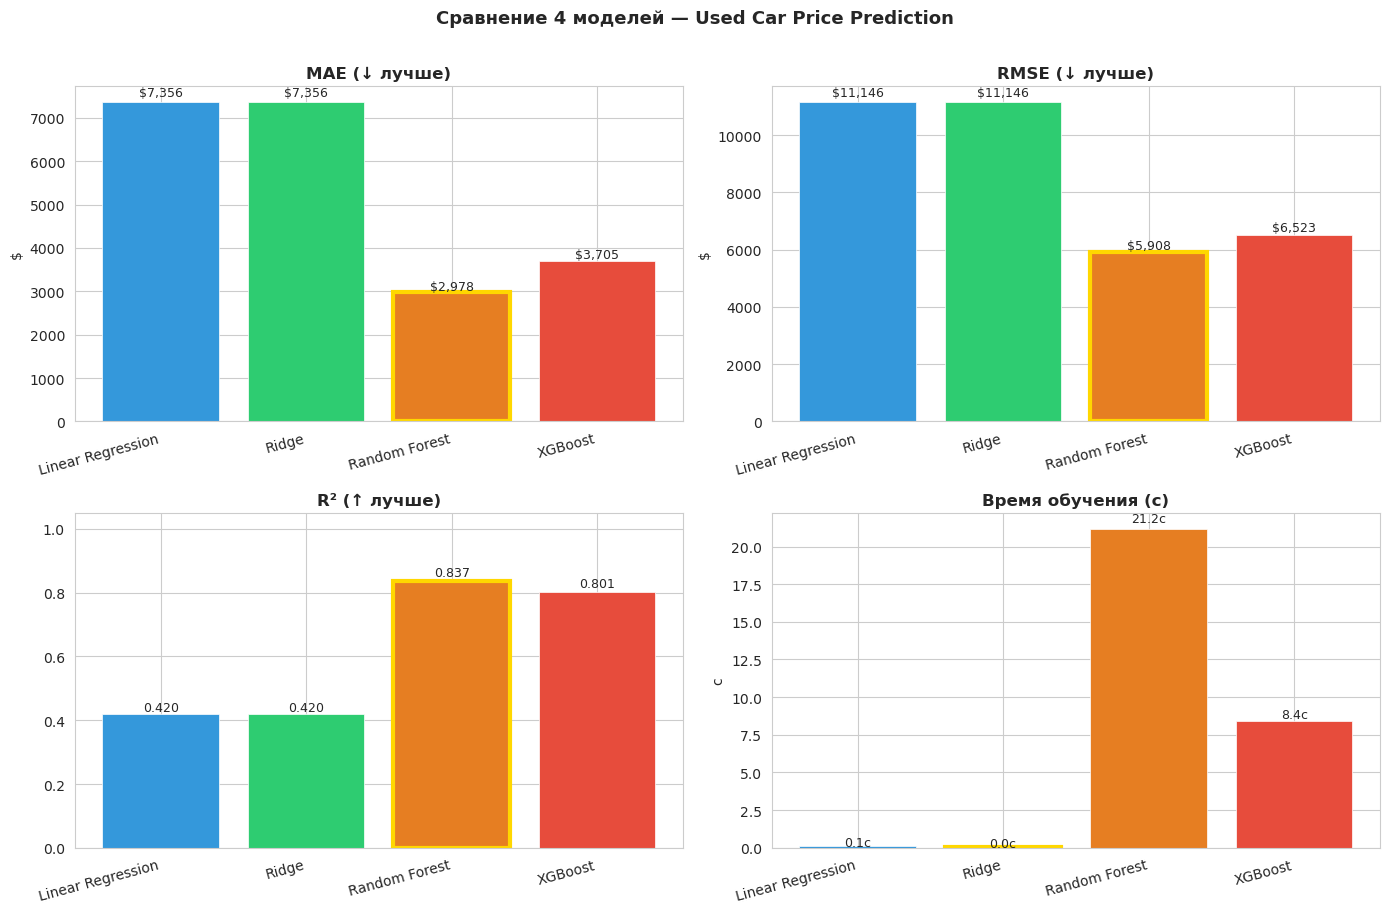

In [34]:
# График сравнения: MAE / RMSE / R²
names  = list(results.keys())
colors = ['#3498db', '#2ecc71', '#e67e22', '#e74c3c']

mae_vals  = [results[n]['MAE']  for n in names]
rmse_vals = [results[n]['RMSE'] for n in names]
r2_vals   = [results[n]['R2']   for n in names]
time_vals = [results[n]['time_s'] for n in names]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

def bar_chart(ax, vals, title, ylabel, fmt, higher_better=False):
    bars = ax.bar(names, vals, color=colors, edgecolor='white', linewidth=0.5)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.set_xticklabels(names, rotation=15, ha='right')
    best_i = int(np.argmax(vals) if higher_better else np.argmin(vals))
    bars[best_i].set_edgecolor('gold')
    bars[best_i].set_linewidth(3)
    for i, v in enumerate(vals):
        ax.text(i, v * 1.02, fmt.format(v), ha='center', fontsize=9)

bar_chart(axes[0,0], mae_vals,  'MAE (↓ лучше)',  '$',  '${:,.0f}')
bar_chart(axes[0,1], rmse_vals, 'RMSE (↓ лучше)', '$',  '${:,.0f}')
bar_chart(axes[1,0], r2_vals,   'R² (↑ лучше)',   '',   '{:.3f}', higher_better=True)
axes[1,0].set_ylim(0, 1.05)
bar_chart(axes[1,1], time_vals, 'Время обучения (с)', 'с', '{:.1f}с')

plt.suptitle('Сравнение 4 моделей — Used Car Price Prediction',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
savefig('model_comparison')
plt.show()

## 11. Feature Importance

../artifacts/exp02_models/feature_importance.png


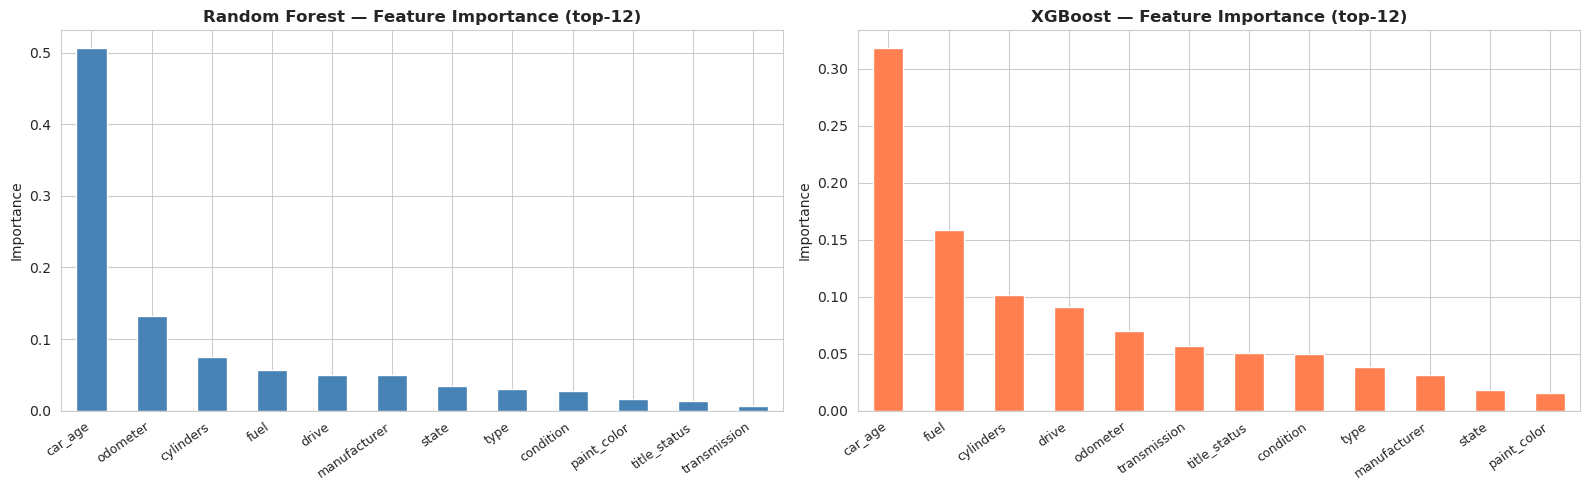

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, model_name, color in [
    (axes[0], 'Random Forest', 'steelblue'),
    (axes[1], 'XGBoost',       'coral'),
]:
    model = results[model_name]['model']
    imp = pd.Series(model.feature_importances_, index=X_train.columns)
    imp.sort_values(ascending=False).head(12).plot(
        kind='bar', ax=ax, color=color, edgecolor='white'
    )
    ax.set_title(f'{model_name} — Feature Importance (top-12)', fontweight='bold')
    ax.set_ylabel('Importance')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=9)

plt.tight_layout()
savefig('feature_importance')
plt.show()

## 12. Анализ ошибок лучшей модели

Лучшая модель: Random Forest  (R² = 0.8370)


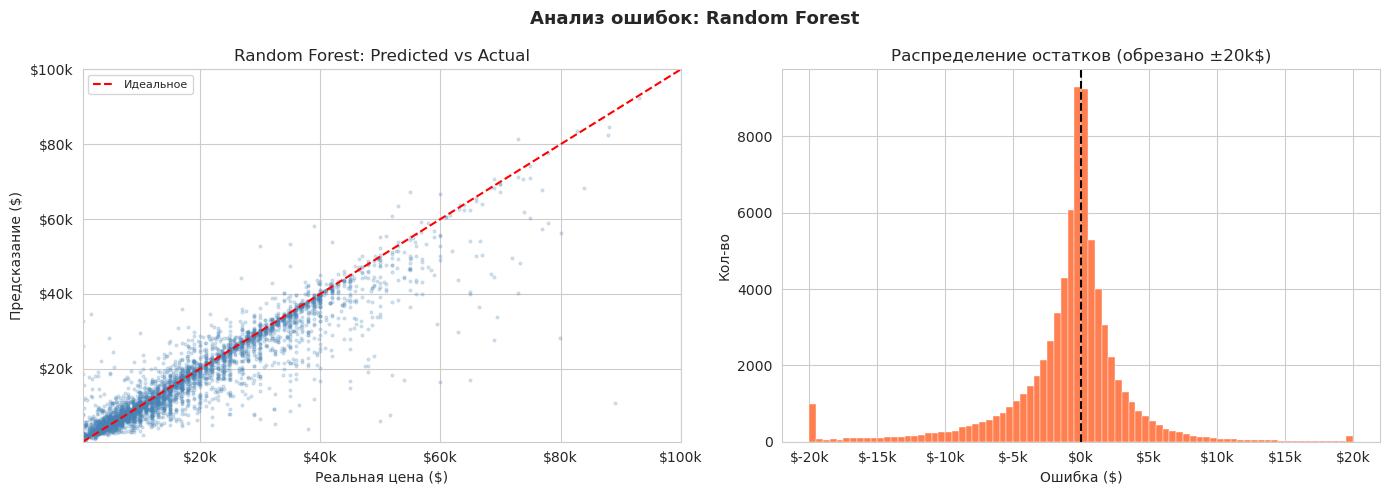


Медиана ошибки : $-198
Std ошибки      : $5,808


In [36]:
best_name = max(results, key=lambda n: results[n]['R2'])
best = results[best_name]
y_true = best['y_true']
y_pred = best['y_pred']
residuals = y_pred - y_true

print(f'Лучшая модель: {best_name}  (R² = {best["R2"]:.4f})')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))  # Изменено на 2 графика

# Predicted vs Actual
idx = np.random.choice(len(y_true), size=min(4000, len(y_true)), replace=False)
axes[0].scatter(y_true[idx], y_pred[idx], alpha=0.2, s=4, color='steelblue')
lim = [500, min(y_true.max(), 100_000)]
axes[0].plot(lim, lim, 'r--', lw=1.5, label='Идеальное')
axes[0].set_xlim(lim)
axes[0].set_ylim(lim)
axes[0].set_xlabel('Реальная цена ($)')
axes[0].set_ylabel('Предсказание ($)')
axes[0].set_title(f'{best_name}: Predicted vs Actual')
axes[0].legend(fontsize=8)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

# Распределение остатков
axes[1].hist(np.clip(residuals, -20_000, 20_000), bins=80,
             color='coral', edgecolor='white', linewidth=0.3)
axes[1].axvline(0, color='black', linestyle='--', lw=1.5)
axes[1].set_xlabel('Ошибка ($)')
axes[1].set_ylabel('Кол-во')
axes[1].set_title('Распределение остатков (обрезано ±20k$)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

plt.suptitle(f'Анализ ошибок: {best_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('error_analysis.png')
plt.show()

print(f'\nМедиана ошибки : ${np.median(residuals):,.0f}')
print(f'Std ошибки      : ${np.std(residuals):,.0f}')

## 13. Примеры предсказаний

In [37]:
best_model = results[best_name]['model']
sample = X_test.sample(10, random_state=0)
actual    = np.expm1(y_test.loc[sample.index])
predicted = np.expm1(best_model.predict(sample))

demo = pd.DataFrame({
    'car_age':   sample['car_age'].values,
    'odometer':  sample['odometer'].values.astype(int),
    'actual ($)':    [f'${v:,.0f}' for v in actual],
    'predicted ($)': [f'${v:,.0f}' for v in predicted],
    'err (%)': [f'{(p-a)/a*100:+.1f}%' for a, p in zip(actual, predicted)],
})
print(f'=== Примеры предсказаний ({best_name}) ===')
print(demo.to_string(index=False))

=== Примеры предсказаний (Random Forest) ===
 car_age  odometer actual ($) predicted ($) err (%)
     5.0     46343    $19,995       $19,103   -4.5%
    17.0     49000     $7,490        $6,955   -7.1%
    13.0    104091    $42,995       $42,547   -1.0%
    11.0    101802    $14,995       $13,840   -7.7%
    13.0    127158     $4,995        $6,372  +27.6%
    21.0    170000     $4,495        $4,740   +5.5%
    11.0    140000     $3,000       $13,961 +365.4%
     5.0     73524    $36,995       $24,808  -32.9%
    11.0    158137    $13,990       $10,016  -28.4%
    18.0    284000    $15,500       $16,106   +3.9%


## 14. Сохранение артефактов

In [38]:
# Сохраняем все 4 модели
for name, res in results.items():
    fname = name.lower().replace(' ', '_')
    path  = MODELS_DIR / f'{fname}.joblib'
    joblib.dump(res['model'], path)
    print(f'{path}')

# Сохраняем scaler (нужен для линейных моделей в инференсе)
joblib.dump(scaler, MODELS_DIR / 'scaler.joblib')
print(f'{MODELS_DIR / "scaler.joblib"}')

# Сохраняем метрики в JSON
metrics_path = ARTIFACTS_DIR / 'metrics.json'
metrics_out  = {
    name: {k: v for k, v in res.items()
           if k not in ('model', 'y_pred', 'y_true')}
    for name, res in results.items()
}
with open(metrics_path, 'w', encoding='utf-8') as f:
    json.dump(metrics_out, f, ensure_ascii=False, indent=2)
print(f'{metrics_path}')

../artifacts/exp02_models/models/linear_regression.joblib
../artifacts/exp02_models/models/ridge.joblib
../artifacts/exp02_models/models/random_forest.joblib
../artifacts/exp02_models/models/xgboost.joblib
../artifacts/exp02_models/models/scaler.joblib
../artifacts/exp02_models/metrics.json
